#### Get all labeled Enhancer regions

In [1]:
def load_enhancer(ipath):
    enhancers = []
    with open(ipath, 'r') as f:
        for line in f:
            line = line.strip().split()
            if len(line) != 3:
                continue
            enhancers.append(line)
    return enhancers

path1 = "Enhancers/active.bed"
path2 = "Enhancers/poised.bed"
path3 = "Enhancers/primed.bed"

enhancers1 = load_enhancer(path1)
enhancers2 = load_enhancer(path2)
enhancers3 = load_enhancer(path3)

fout = open("Enhancers/labeled_enhancers.bed", "w")
with open("Enhancers/labeled_enhancers.bed", "w") as fout:
    for enhancer in enhancers1:
        out1 = "\t".join(enhancer) + "\t" + "active\n"
        fout.write(out1)
    for enhancer in enhancers2:
        out2 = "\t".join(enhancer) + "\t" + "poised\n"
        fout.write(out2)
    for enhancer in enhancers3:
        out3 = "\t".join(enhancer) + "\t" + "primed\n"
        fout.write(out3)

#### Average between replicates for H3K4me1 6B-CnT data

In [8]:
import numpy as np

path1 = '6B/H3K4Me1_rep1.genome.GRCm38_primary_assembly.dedup.duet-evoC.CG_quant.combined.tsv'
path2 = '6B/H3K4Me1_rep2.genome.GRCm38_primary_assembly.dedup.duet-evoC.CG_quant.combined.tsv'
path3 = '6B/H3K4Me1_rep3.genome.GRCm38_primary_assembly.dedup.duet-evoC.CG_quant.combined.tsv'

rep1_dic = {}
rep2_dic = {}
rep3_dic = {}

total_nums1 = 0
total_nums2 = 0
total_nums3 = 0

with open(path1, 'r') as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 7 or line[0] == '#':
            continue

        if len(line[0]) > 5:
            continue

        k = f"chr{line[0]}:{line[1]}"
        rep1_dic[k] = np.array([int(i) for i in line[2:]])

        total_nums1 += int(line[-1])

with open(path2, 'r') as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 7 or line[0] == '#':
            continue

        if len(line[0]) > 5:
            continue

        k = f"chr{line[0]}:{line[1]}"
        rep2_dic[k] = np.array([int(i) for i in line[2:]])

        total_nums2 += int(line[-1])

with open(path3, 'r') as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 7 or line[0] == '#':
            continue

        if len(line[0]) > 5:
            continue

        k = f"chr{line[0]}:{line[1]}"
        rep3_dic[k] = np.array([int(i) for i in line[2:]])

        total_nums3 += int(line[-1])

size_factor1 = 10000000 / total_nums1
size_factor2 = 10000000 / total_nums2
size_factor3 = 10000000 / total_nums3

fout = open("6B/H3K4Me1_reps_avg.bed", "w")

for k in rep1_dic.keys():
    nums1 = rep1_dic[k]

    try:
        nums2 = rep2_dic[k]
    except:
        continue

    try:
        nums3 = rep3_dic[k]
    except:
        continue

    num = (nums1 * size_factor1 + nums2 * size_factor2 + nums3 * size_factor3) / 3

    if num.sum() == 0:
        continue

    chrom = k.split(":")[0]
    start = int(k.split(":")[1])
    end  = start + 1
    out = f"{chrom}\t{start}\t{end}\t" + "\t".join([f"{i:.4f}" for i in num]) + "\n"
    fout.write(out)


#### Map 6B data to enhancers

In [9]:
import os

cmd1 = "sort -k1,1 -k2,2n -k3,3n 6B/H3K4Me1_reps_avg.bed > 6B/H3K4Me1_reps_avg.sorted.bed"
os.system(cmd1)

cmd = f"bedtools intersect -wa -wb -a 6B/H3K4Me1_reps_avg.sorted.bed -b Enhancers/labeled_enhancers.bed | sort -k1,1 -k2,2n -k3,3n > H3K4Me1_6B_in_enhancers.bed"
os.system(cmd)

0

#### Construct input features

In [10]:
import pickle
from collections import defaultdict

enhancers_modC = defaultdict(int)

with open("H3K4Me1_6B_in_enhancers.bed", "r") as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 12:
            continue

        enhancer_id = f"{line[-4]}:{line[-3]}-{line[-2]}"
        enhancers_modC[enhancer_id] += 1

In [12]:
vals = list(enhancers_modC.values())

max(vals)

419

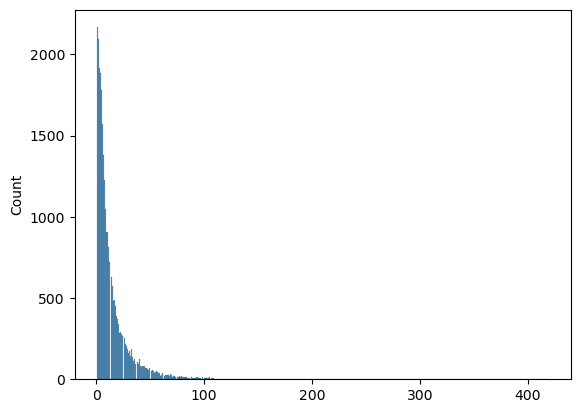

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(vals)
plt.show()

In [14]:
import pickle
from collections import defaultdict

enhancers_modC = defaultdict(list)

with open("H3K4Me1_6B_in_enhancers.bed", "r") as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 12:
            continue

        enhancer_id = f"{line[-4]}:{line[-3]}-{line[-2]},{line[-1]}"
        enhancers_modC[enhancer_id].append([float(v) for v in line[3:7]])

fout = open("H3K4Me1_6B_in_enhancers_modC.pkl", "wb")
pickle.dump(enhancers_modC, fout)

### Section 2: Process WG control data

In [2]:
import numpy as np

path1 = 'WG_control/WG_rep1.genome.GRCm38p6_primary_assembly.dedup.duet-evoC.CG_quant.combined.tsv'
path2 = 'WG_control/WG_rep2.genome.GRCm38p6_primary_assembly.dedup.duet-evoC.CG_quant.combined.tsv'

rep1_dic = {}
rep2_dic = {}

total_nums1 = 0
total_nums2 = 0

with open(path1, 'r') as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 7 or line[0] == '#':
            continue

        if len(line[0]) > 5:
            continue

        k = f"{line[0]}:{line[1]}"
        rep1_dic[k] = np.array([int(i) for i in line[2:]])

        total_nums1 += int(line[-1])

with open(path2, 'r') as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 7 or line[0] == '#':
            continue

        if len(line[0]) > 5:
            continue

        k = f"{line[0]}:{line[1]}"
        rep2_dic[k] = np.array([int(i) for i in line[2:]])

        total_nums2 += int(line[-1])

size_factor1 = 10000000 / total_nums1
size_factor2 = 10000000 / total_nums2

fout = open("WG_control/WG_reps_avg.bed", "w")

for k in rep1_dic.keys():
    nums1 = rep1_dic[k]

    try:
        nums2 = rep2_dic[k]
    except:
        continue

    num = (nums1 * size_factor1 + nums2 * size_factor2) / 2

    if num.sum() == 0:
        continue

    chrom = k.split(":")[0]
    start = int(k.split(":")[1])
    end  = start + 1
    out = f"{chrom}\t{start}\t{end}\t" + "\t".join([f"{i:.4f}" for i in num]) + "\n"
    fout.write(out)

In [1]:
import os

cmd1 = "sort -k1,1 -k2,2n -k3,3n WG_control/WG_reps_avg.bed > WG_control/WG_reps_avg.sorted.bed"
os.system(cmd1)

cmd = f"bedtools intersect -wa -wb -a WG_control/WG_reps_avg.sorted.bed -b Enhancers/labeled_enhancers.bed | sort -k1,1 -k2,2n -k3,3n > WG_control_in_enhancers.bed"
os.system(cmd)

0

In [2]:
import pickle
from collections import defaultdict

enhancers_modC = defaultdict(int)

with open("WG_control_in_enhancers.bed", "r") as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 12:
            continue

        enhancer_id = f"{line[-4]}:{line[-3]}-{line[-2]}"
        enhancers_modC[enhancer_id] += 1

In [3]:
vals = list(enhancers_modC.values())

max(vals)

482

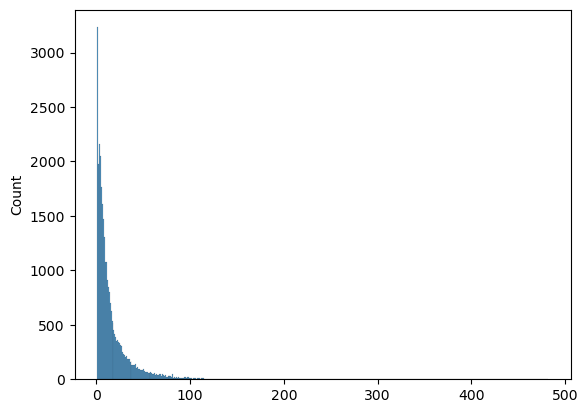

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(vals)
plt.show()

In [5]:
import pickle
from collections import defaultdict

enhancers_modC = defaultdict(list)

with open("WG_control_in_enhancers.bed", "r") as f:
    for line in f:
        line = line.strip().split()

        if len(line) != 12:
            continue

        enhancer_id = f"{line[-4]}:{line[-3]}-{line[-2]},{line[-1]}"
        enhancers_modC[enhancer_id].append([float(v) for v in line[3:7]])

fout = open("WG_control_in_enhancers_modC.pkl", "wb")
pickle.dump(enhancers_modC, fout)

#### Process prediction results

In [43]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [44]:
preddir = '/home/xuan/Projects/MLfor6BCnT/model/selfAttn'

df1 = pd.read_csv(f"{preddir}/chr1_6BCnT_predictions_by_model_trained_on_6BCnT.txt", sep='\t', header=0, index_col=0)
df2 = pd.read_csv(f"{preddir}/chr1_6BWG_predictions_by_model_trained_on_6BWG.txt", sep='\t', header=0, index_col=0)
df3 = pd.read_csv(f"{preddir}/chr1_6BCnT_predictions_by_model_trained_on_6BWG.txt", sep='\t', header=0, index_col=0) # WG-CnT
df4 = pd.read_csv(f"{preddir}/chr1_6BWG_predictions_by_model_trained_on_6BCnT.txt", sep='\t', header=0, index_col=0) # CnT-WG

In [45]:
df4

,prob_active,prob_poised,prob_primed,pred,label
Ehancer,,,,,
"chr1:153206361-153207517,primed",1.075645e-01,0.108988,0.783448,2,2
"chr1:35869603-35871629,primed",1.336947e-03,0.025948,0.972715,2,2
"chr1:98073176-98073604,active",7.314008e-01,0.239033,0.029566,0,0
"chr1:167374036-167375219,primed",1.583041e-03,0.010256,0.988161,2,2
"chr1:61417253-61418362,primed",4.227318e-02,0.030720,0.927007,2,2
...,...,...,...,...,...
"chr1:161251773-161257837,primed",2.200012e-07,0.000004,0.999995,2,2
"chr1:173336111-173337462,primed",1.507479e-02,0.008033,0.976892,2,2
"chr1:136540396-136541556,primed",1.455375e-02,0.002570,0.982876,2,2


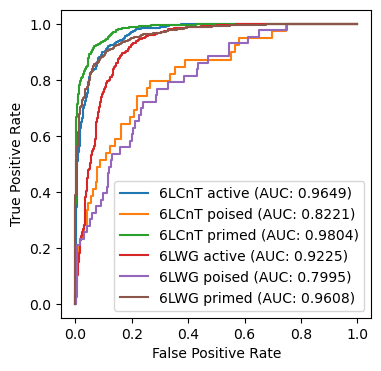

In [46]:
active_labels1 = (df1['label'] == 0).values.astype(float)
poised_labels1 = (df1['label'] == 1).values.astype(float)
primed_labels1 = (df1['label'] == 2).values.astype(float)

active_probs1 = df1['prob_active'].values
poised_probs1 = df1['prob_poised'].values
primed_probs1 = df1['prob_primed'].values

active_labels2 = (df2['label'] == 0).values.astype(float)
poised_labels2 = (df2['label'] == 1).values.astype(float)
primed_labels2 = (df2['label'] == 2).values.astype(float)

active_probs2 = df2['prob_active'].values
poised_probs2 = df2['prob_poised'].values
primed_probs2 = df2['prob_primed'].values

fpr1, tpr1, _ = roc_curve(active_labels1, active_probs1, pos_label=1)
fpr2, tpr2, _ = roc_curve(poised_labels1, poised_probs1, pos_label=1)
fpr3, tpr3, _ = roc_curve(primed_labels1, primed_probs1, pos_label=1)

fpr4, tpr4, _ = roc_curve(active_labels2, active_probs2, pos_label=1)
fpr5, tpr5, _ = roc_curve(poised_labels2, poised_probs2, pos_label=1)
fpr6, tpr6, _ = roc_curve(primed_labels2, primed_probs2, pos_label=1)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)
auc4 = auc(fpr4, tpr4)
auc5 = auc(fpr5, tpr5)
auc6 = auc(fpr6, tpr6)

plt.figure(figsize=(4, 4))
plt.plot(fpr1, tpr1, label='6BCnT active (AUC: {:.4f})'.format(auc1))
plt.plot(fpr2, tpr2, label='6BCnT poised (AUC: {:.4f})'.format(auc2))
plt.plot(fpr3, tpr3, label='6BCnT primed (AUC: {:.4f})'.format(auc3))
plt.plot(fpr4, tpr4, label='6BWG active (AUC: {:.4f})'.format(auc4))
plt.plot(fpr5, tpr5, label='6BWG poised (AUC: {:.4f})'.format(auc5))
plt.plot(fpr6, tpr6, label='6BWG primed (AUC: {:.4f})'.format(auc6))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

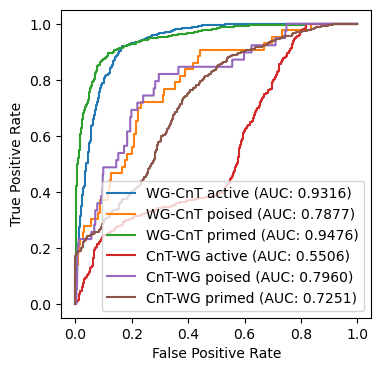

In [47]:
active_labels1 = (df3['label'] == 0).values.astype(float)
poised_labels1 = (df3['label'] == 1).values.astype(float)
primed_labels1 = (df3['label'] == 2).values.astype(float)

active_probs1 = df3['prob_active'].values
poised_probs1 = df3['prob_poised'].values
primed_probs1 = df3['prob_primed'].values

active_labels2 = (df4['label'] == 0).values.astype(float)
poised_labels2 = (df4['label'] == 1).values.astype(float)
primed_labels2 = (df4['label'] == 2).values.astype(float)

active_probs2 = df4['prob_active'].values
poised_probs2 = df4['prob_poised'].values
primed_probs2 = df4['prob_primed'].values

fpr1, tpr1, _ = roc_curve(active_labels1, active_probs1, pos_label=1)
fpr2, tpr2, _ = roc_curve(poised_labels1, poised_probs1, pos_label=1)
fpr3, tpr3, _ = roc_curve(primed_labels1, primed_probs1, pos_label=1)

fpr4, tpr4, _ = roc_curve(active_labels2, active_probs2, pos_label=1)
fpr5, tpr5, _ = roc_curve(poised_labels2, poised_probs2, pos_label=1)
fpr6, tpr6, _ = roc_curve(primed_labels2, primed_probs2, pos_label=1)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)
auc4 = auc(fpr4, tpr4)
auc5 = auc(fpr5, tpr5)
auc6 = auc(fpr6, tpr6)

plt.figure(figsize=(4, 4))
plt.plot(fpr1, tpr1, label='WG-CnT active (AUC: {:.4f})'.format(auc1))
plt.plot(fpr2, tpr2, label='WG-CnT poised (AUC: {:.4f})'.format(auc2))
plt.plot(fpr3, tpr3, label='WG-CnT primed (AUC: {:.4f})'.format(auc3))
plt.plot(fpr4, tpr4, label='CnT-WG active (AUC: {:.4f})'.format(auc4))
plt.plot(fpr5, tpr5, label='CnT-WG poised (AUC: {:.4f})'.format(auc5))
plt.plot(fpr6, tpr6, label='CnT-WG primed (AUC: {:.4f})'.format(auc6))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

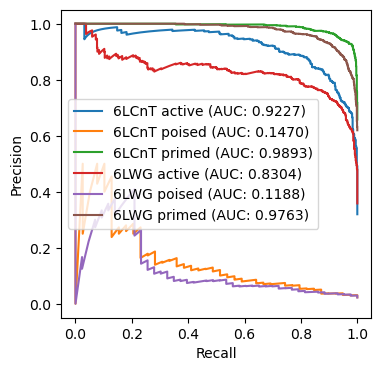

In [48]:
active_labels1 = (df1['label'] == 0).values.astype(float)
poised_labels1 = (df1['label'] == 1).values.astype(float)
primed_labels1 = (df1['label'] == 2).values.astype(float)

active_probs1 = df1['prob_active'].values
poised_probs1 = df1['prob_poised'].values
primed_probs1 = df1['prob_primed'].values

active_labels2 = (df2['label'] == 0).values.astype(float)
poised_labels2 = (df2['label'] == 1).values.astype(float)
primed_labels2 = (df2['label'] == 2).values.astype(float)

active_probs2 = df2['prob_active'].values
poised_probs2 = df2['prob_poised'].values
primed_probs2 = df2['prob_primed'].values

precision1, recall1, _ = precision_recall_curve(active_labels1, active_probs1, pos_label=1)
precision2, recall2, _ = precision_recall_curve(poised_labels1, poised_probs1, pos_label=1)
precision3, recall3, _ = precision_recall_curve(primed_labels1, primed_probs1, pos_label=1)

precision4, recall4, _ = precision_recall_curve(active_labels2, active_probs2, pos_label=1)
precision5, recall5, _ = precision_recall_curve(poised_labels2, poised_probs2, pos_label=1)
precision6, recall6, _ = precision_recall_curve(primed_labels2, primed_probs2, pos_label=1)

auc1 = auc(recall1, precision1)
auc2 = auc(recall2, precision2)
auc3 = auc(recall3, precision3)
auc4 = auc(recall4, precision4)
auc5 = auc(recall5, precision5)
auc6 = auc(recall6, precision6)

plt.figure(figsize=(4, 4))
plt.plot(recall1, precision1, label='6BCnT active (AUC: {:.4f})'.format(auc1))
plt.plot(recall2, precision2, label='6BCnT poised (AUC: {:.4f})'.format(auc2))
plt.plot(recall3, precision3, label='6BCnT primed (AUC: {:.4f})'.format(auc3))
plt.plot(recall4, precision4, label='6BWG active (AUC: {:.4f})'.format(auc4))
plt.plot(recall5, precision5, label='6BWG poised (AUC: {:.4f})'.format(auc5))
plt.plot(recall6, precision6, label='6BWG primed (AUC: {:.4f})'.format(auc6))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

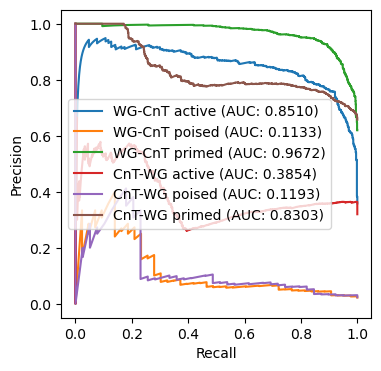

In [49]:
active_labels1 = (df3['label'] == 0).values.astype(float)
poised_labels1 = (df3['label'] == 1).values.astype(float)
primed_labels1 = (df3['label'] == 2).values.astype(float)

active_probs1 = df3['prob_active'].values
poised_probs1 = df3['prob_poised'].values
primed_probs1 = df3['prob_primed'].values

active_labels2 = (df4['label'] == 0).values.astype(float)
poised_labels2 = (df4['label'] == 1).values.astype(float)
primed_labels2 = (df4['label'] == 2).values.astype(float)

active_probs2 = df4['prob_active'].values
poised_probs2 = df4['prob_poised'].values
primed_probs2 = df4['prob_primed'].values

precision1, recall1, _ = precision_recall_curve(active_labels1, active_probs1, pos_label=1)
precision2, recall2, _ = precision_recall_curve(poised_labels1, poised_probs1, pos_label=1)
precision3, recall3, _ = precision_recall_curve(primed_labels1, primed_probs1, pos_label=1)

precision4, recall4, _ = precision_recall_curve(active_labels2, active_probs2, pos_label=1)
precision5, recall5, _ = precision_recall_curve(poised_labels2, poised_probs2, pos_label=1)
precision6, recall6, _ = precision_recall_curve(primed_labels2, primed_probs2, pos_label=1)

auc1 = auc(recall1, precision1)
auc2 = auc(recall2, precision2)
auc3 = auc(recall3, precision3)
auc4 = auc(recall4, precision4)
auc5 = auc(recall5, precision5)
auc6 = auc(recall6, precision6)

plt.figure(figsize=(4, 4))
plt.plot(recall1, precision1, label='WG-CnT active (AUC: {:.4f})'.format(auc1))
plt.plot(recall2, precision2, label='WG-CnT poised (AUC: {:.4f})'.format(auc2))
plt.plot(recall3, precision3, label='WG-CnT primed (AUC: {:.4f})'.format(auc3))
plt.plot(recall4, precision4, label='CnT-WG active (AUC: {:.4f})'.format(auc4))
plt.plot(recall5, precision5, label='CnT-WG poised (AUC: {:.4f})'.format(auc5))
plt.plot(recall6, precision6, label='CnT-WG primed (AUC: {:.4f})'.format(auc6))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

#### Multiclass ROC

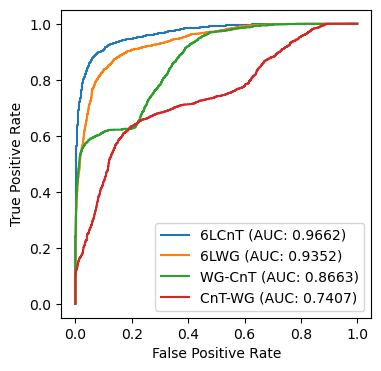

In [52]:
one_hot_labels1 = np.zeros((len(df1), 3))
one_hot_labels1[np.arange(len(df1)), df1['label'].values] = 1

one_hot_labels2 = np.zeros((len(df2), 3))
one_hot_labels2[np.arange(len(df2)), df2['label'].values] = 1

one_hot_labels3 = np.zeros((len(df3), 3))
one_hot_labels3[np.arange(len(df3)), df3['label'].values] = 1

one_hot_labels4 = np.zeros((len(df4), 3))
one_hot_labels4[np.arange(len(df4)), df4['label'].values] = 1

probs1 = df1[['prob_active', 'prob_poised', 'prob_primed']].values
probs2 = df2[['prob_active', 'prob_poised', 'prob_primed']].values
probs3 = df3[['prob_active', 'prob_poised', 'prob_primed']].values
probs4 = df4[['prob_active', 'prob_poised', 'prob_primed']].values

fpr1, tpr1, _ = roc_curve(one_hot_labels1.ravel(), probs1.ravel(), pos_label=1)
fpr2, tpr2, _ = roc_curve(one_hot_labels2.ravel(), probs2.ravel(), pos_label=1)
fpr3, tpr3, _ = roc_curve(one_hot_labels3.ravel(), probs3.ravel(), pos_label=1)
fpr4, tpr4, _ = roc_curve(one_hot_labels4.ravel(), probs4.ravel(), pos_label=1)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)
auc4 = auc(fpr4, tpr4)

plt.figure(figsize=(4, 4))
plt.plot(fpr1, tpr1, label='6BCnT (AUC: {:.4f})'.format(auc1))
plt.plot(fpr2, tpr2, label='6BWG (AUC: {:.4f})'.format(auc2))
plt.plot(fpr3, tpr3, label='WG-CnT (AUC: {:.4f})'.format(auc3))
plt.plot(fpr4, tpr4, label='CnT-WG (AUC: {:.4f})'.format(auc4))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

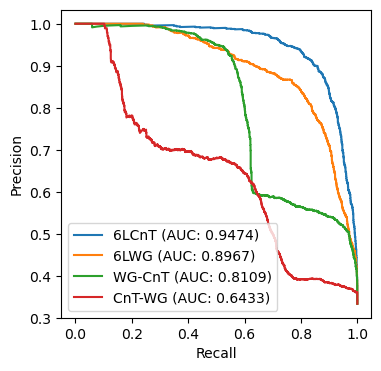

In [53]:
precision1, recall1, _ = precision_recall_curve(one_hot_labels1.ravel(), probs1.ravel(), pos_label=1)
precision2, recall2, _ = precision_recall_curve(one_hot_labels2.ravel(), probs2.ravel(), pos_label=1)
precision3, recall3, _ = precision_recall_curve(one_hot_labels3.ravel(), probs3.ravel(), pos_label=1)
precision4, recall4, _ = precision_recall_curve(one_hot_labels4.ravel(), probs4.ravel(), pos_label=1)

auc1 = auc(recall1, precision1)
auc2 = auc(recall2, precision2)
auc3 = auc(recall3, precision3)
auc4 = auc(recall4, precision4)

plt.figure(figsize=(4, 4))
plt.plot(recall1, precision1, label='6BCnT (AUC: {:.4f})'.format(auc1))
plt.plot(recall2, precision2, label='6BWG (AUC: {:.4f})'.format(auc2))
plt.plot(recall3, precision3, label='WG-CnT (AUC: {:.4f})'.format(auc3))
plt.plot(recall4, precision4, label='CnT-WG (AUC: {:.4f})'.format(auc4))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()


#### Interpretability of the attention weights

In [71]:
import pickle

pred_dir = '/home/xuan/Projects/MLfor6BCnT/model/selfAttn/predictions/predictions_with_random_seed20250520'

with open(f'{pred_dir}/6BWG_predictions_attn.pkl', 'rb') as f:
    enhancers_Wattns1 = pickle.load(f)

with open(f'{pred_dir}/6BCnT_predictions_attn.pkl', 'rb') as f:
    enhancers_Wattns2 = pickle.load(f)

In [77]:
enhancers_Wattns1

{'chr5:38656242-38656633,active': array([[0.00361364, 0.0036105 , 0.00361456, 0.0036199 , 0.00361173,
         0.00361355],
        [0.0036111 , 0.00361014, 0.00361306, 0.00361889, 0.00360824,
         0.00360982],
        [0.00361264, 0.00360977, 0.00361369, 0.00361916, 0.00361069,
         0.00361271],
        [0.00361161, 0.00360864, 0.00361259, 0.00361809, 0.00360977,
         0.00361201],
        [0.00361449, 0.00361239, 0.00361592, 0.00362128, 0.00361193,
         0.00361294],
        [0.00361408, 0.00361429, 0.00361663, 0.0036222 , 0.00361026,
         0.00361008]], dtype=float32),
 'chr9:6823890-6824336,active': array([[0.00344555]], dtype=float32),
 'chr19:45299872-45300146,poised': array([[0.00361555, 0.00353944, 0.00355171, 0.00355585, 0.00359783],
        [0.00361231, 0.00353333, 0.00354585, 0.00355029, 0.00359586],
        [0.00361529, 0.00353473, 0.00354554, 0.00355294, 0.00360015],
        [0.00361173, 0.00353541, 0.00354909, 0.00355104, 0.00359379],
        [0.00360743,

In [78]:
mat1 = enhancers_Wattns1['chr5:38656242-38656633,active']
mat2 = enhancers_Wattns2['chr5:38656242-38656633,active']

mat1.shape, mat2.shape

mat1.sum(), mat2.sum()

(0.13008302, 0.29739526)